<a href="https://colab.research.google.com/github/psm-optimizes/HOIPM4SDO/blob/main/HOIPM4SDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Packages and Functions**

In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
from scipy import linalg
from copy import deepcopy
from scipy.stats import ortho_group
from scipy.io import savemat
import math
import time
import random

In [ ]:
np.set_printoptions(edgeitems=30, linewidth=100000)

In [ ]:
def is_pos_def(x):
  return np.all(np.linalg.eigvals(x) > 0)

def hvec(A):
	n=len(A)
	s=[]
	for i in range(n):
		for j in range(n):
			s.append(A[i,j])
	return np.array(s)

def hmat(s):
  n=int(np.sqrt(len(s)))
  A=np.zeros((n,n))
  t=0
  for i in range(n):
    for j in range(n):
      A[i,j]=s[t]
      t=t+1
  return A

def svec(A):
  n=len(A)
  s=[]
  for i in range(n):
    s.append(A[i,i])
    for j in range(i+1,n):
      s.append(np.sqrt(2)*A[i,j])
  return np.array(s)

def smat(s):
  n=int(np.floor(np.sqrt(2*len(s))))
  A=np.zeros((n,n))
  t=0
  for i in range(n):
    A[i,i]=s[t]
    t=t+1
    for j in range(i+1,n):
      A[i,j]=s[t]/np.sqrt(2)
      A[j,i]=s[t]/np.sqrt(2)
      t=t+1
  return A

In [ ]:
def symet(M,type):
	if type=="AHO":
		return 0.5*(M+M.T)
	elif type=="NT":
		# Dmid = np.linalg.cholesky(np.matmul(np.matmul(np.linalg.cholesky(S),X),np.linalg.cholesky(S)))
		# D = np.matmul(np.matmul(invsqrt(S),Dmid), invsqrt(S))
		Wmid = invsqrt(np.matmul(np.matmul(np.linalg.cholesky(X),S),np.linalg.cholesky(X)))
		W = np.matmul(np.matmul(np.linalg.cholesky(X),Wmid), np.linalg.cholesky(X))
		P = np.linalg.cholesky(W)
		return 0.5*(np.matmul(np.matmul(P,M),np.linalg.inv(P)) + np.transpose(np.matmul(np.matmul(P,M),np.linalg.inv(P))))
	elif type=="HRV":
		return 0.5*(np.matmul(np.matmul(np.linalg.cholesky(S),M),invsqrt(S)) + np.transpose(np.matmul(np.matmul(np.linalg.cholesky(S),M),invsqrt(S))))
	elif type=="KSS":
		return 0.5*(np.matmul(np.matmul(invsqrt(X),M),np.linalg.cholesky(X)) + np.transpose(np.matmul(np.matmul(invsqrt(X),M),np.linalg.cholesky(X))))

# **AHO**

In [ ]:
#@markdown **Basic version of AHO IPM (SDOIPM_AHO)**

#===========================================================================
# IPM for SDO - AHO
#===========================================================================
def SDOIPM_AHO(A,b,C,m,n,X0,y0,S0,precision):
  #-----------------------------------------------------------------------
  # Initialize the paramters of the algorithm
  #-----------------------------------------------------------------------
  beta      = 0.9
  tol       = 0.2
  # 10**(-3)
  cent_tol  = 10**(-5)
  mu_record = []

  n2=n*n
  AA = np.zeros((m,n2))
  for i in range(m):
    t=hvec(A[i,:,:])
    for j in range(len(t)):
      AA[i,j]=t[j]

  X = X0
  S = S0
  y = y0
  # print('Init. Proximity:',np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ))

  if np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ) > cent_tol:
    while (True):
      #-------------------------------------------------------------------
      # Calculate complementarity
      #-------------------------------------------------------------------
      mu_cent 		= (np.trace(np.matmul(X,S))) / (n)
      #-------------------------------------------------------------------
      # Build the system
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S), 'AHO')
      RC  = hvec((mu_cent)*np.eye(n) - XS)
      r 	= np.block([np.zeros(n2+m), RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z	= np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy	    = z[n2:n2+m]
      vds	    = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      Alpha = 0.1

      S   = S + Alpha*delta_s
      X   = X + Alpha*delta_x
      y   = y + Alpha*delta_y
      # print('Cent. Proximity:',np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ))
      if np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ) <= cent_tol:
        break

  mu_record = np.append(mu_record, np.trace(np.matmul(X,S))/n)
  #-----------------------------------------------------------------------
  # Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    #-------------------------------------------------------------------
    # Calculate complementarity
    #-------------------------------------------------------------------
    mu 		= (np.trace(np.matmul(X,S))) / (n)
    #-------------------------------------------------------------------
    # Build the system
    #-------------------------------------------------------------------
    EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
    FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
    M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                    [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                    [EE,                np.zeros((n2,m)), FF]])
    XS  = symet(np.matmul(X,S), 'AHO')
    RC  = hvec((beta*mu)*np.eye(n) - XS)
    r 	= np.block([np.zeros(n2+m), RC])
    #-------------------------------------------------------------------
    # Linear system solver solution
    #-------------------------------------------------------------------
    z	= np.linalg.solve(M, r)
    #-------------------------------------------------------------------
    # Calculate delta_x and delta_s
    #-------------------------------------------------------------------
    vdx     = z[:n2]
    vdy	    = z[n2:n2+m]
    vds	    = z[n2+m:]
    delta_x = hmat(vdx)
    delta_y = vdy
    delta_s = hmat(vds)

    alpha = 1
    SS   = S + alpha*delta_s
    XX   = X + alpha*delta_x
    yy   = y + alpha*delta_y

    mu_temp 		= (np.trace(np.matmul(XX,SS))) / (n)
    # print('mu_temp:', mu_temp)

    while np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*((np.trace(np.matmul(XX,SS))) / (n)))) - np.eye(n) ) > tol:
      # print('Temp. Proximity:',np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*((np.trace(np.matmul(XX,SS))) / (n)))) - np.eye(n) ))
      alpha = 0.9*alpha
      SS   = S + alpha*delta_s
      XX   = X + alpha*delta_x
      yy   = y + alpha*delta_y

    S   = SS
    X   = XX
    y   = yy

    mu_record = np.append(mu_record, np.trace(np.matmul(X,S))/n)

    #-------------------------------------------------------------------
    # Stopping condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ): break

    ## Primal feasibility
    for i in range(m):
      if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
        print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

    ## Dual feasibility
    c_temp = np.zeros((n,n))
    for i in range(m):
      c_temp = c_temp + y[i]*A[i,]

    if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
      print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n), mu_record)

In [ ]:
#@markdown **AHO IPM with Centering (SDOIPM)**

#===========================================================================
# IPM for SDO - AHO
#===========================================================================
def SDOIPM(A,b,C,m,n,X0,y0,S0,precision):
  #-----------------------------------------------------------------------
  # Initialize the paramters of the algorithm
  #-----------------------------------------------------------------------
  beta      = 0.9
  tol       = 0.2
  # 10**(-3)
  cent_tol  = 10**(-5)
  alpha     = 0.1
  mu_Crecord = []

  n2=n*n
  AA = np.zeros((m,n2))
  for i in range(m):
    t=hvec(A[i,:,:])
    for j in range(len(t)):
      AA[i,j]=t[j]

  X = X0
  S = S0
  y = y0

  mu_init = (np.trace(np.matmul(X,S))) / (n)
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_init)) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
      # Initial Centering
      #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((mu_init)*np.eye(n) - XS)
      r 	= np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z	  = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy	    = z[n2:n2+m]
      vds	    = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      # cent = np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n))

      S 		  = S + alpha*delta_s
      X 		  = X + alpha*delta_x
      y 		  = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_init)) - np.eye(n) )  <= cent_tol): break

      # while np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n)) > 0.95*cent and ~is_pos_def(X) and ~is_pos_def(S):
      #     alpha = 0.5*alpha
      #     X     = X + alpha*delta_x
      #     S     = S + alpha*delta_s
      #     y     = y + alpha*delta_y
      #     print(alpha)
      #     print(np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n)))
      #     if alpha < 10**(-3):
      #       break
      # if (np.linalg.norm(np.matmul(X,S)-mu*np.eye(n))  <= tol  ): break


  mu_Crecord = np.append(mu_Crecord, (np.trace(np.matmul(X,S))) / (n))
  #-----------------------------------------------------------------------
  # Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    #-------------------------------------------------------------------
    # Calculate complementarity
    #-------------------------------------------------------------------
    mu 		= (np.trace(np.matmul(X,S))) / (n)
    # print('Temp. Comp.:', mu)
    #-------------------------------------------------------------------
    # Calculate the intermediate terms
    #-------------------------------------------------------------------
    EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
    FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
    M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                    [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                    [EE,                np.zeros((n2,m)), FF]])
    XS  = symet(np.matmul(X,S),"AHO")
    RC  = hvec((beta*mu)*np.eye(n) - XS)
    r 	= np.block([np.zeros(n2+m), RC])
    #-------------------------------------------------------------------
    # Linear system solver solution
    #-------------------------------------------------------------------
    z	= np.linalg.solve(M, r)
    #-------------------------------------------------------------------
    # Calculate delta_x and delta_s
    #-------------------------------------------------------------------
    vdx     = z[:n2]
    vdy	    = z[n2:n2+m]
    vds	    = z[n2+m:]
    delta_x = hmat(vdx)
    delta_y = vdy
    delta_s = hmat(vds)

    # ## Primal feasibility
    # for i in range(m):
    #   if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
    #     print('Newton Step - Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

    # ## Dual feasibility
    # c_temp = np.zeros((n,n))
    # for i in range(m):
    #   c_temp = c_temp + y[i]*A[i,]

    # if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    #   print('Newton Step -  Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

    alpha2 = 1
    SS   = S + alpha2*delta_s
    XX   = X + alpha2*delta_x
    yy   = y + alpha2*delta_y
    mu_temp 		= (np.trace(np.matmul(XX,SS))) / (n)
    while np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp)) - np.eye(n) ) > tol:
      alpha2 = 0.5*alpha2
      # print('first alpha2 is ',alpha2)
      SS   = S + alpha2*delta_s
      XX   = X + alpha2*delta_x
      yy   = y + alpha2*delta_y
      mu_temp 		= (np.trace(np.matmul(XX,SS))) / (n)

    S   = S + alpha2*delta_s
    X   = X + alpha2*delta_x
    y   = y + alpha2*delta_y
    # print('the target is', beta*mu, 'and X is \n',X, '\n and S is \n',S)

    #################################
    ### Centering after each scaling
    #################################

    if np.linalg.norm(((np.matmul(X,S)+np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))/n))) - np.eye(n))  > cent_tol:
      while (True):
        # print('predictor error is', np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_temp2)) - np.eye(n)) )
        #-------------------------------------------------------------------
        # Calculate the intermediate terms
        #-------------------------------------------------------------------
        mu_temp2 = (np.trace(np.matmul(X,S))) / (n)

        EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
        FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
        M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                        [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                        [EE,                np.zeros((n2,m)), FF]])
        XS  = symet(np.matmul(X,S),"AHO")
        RC  = hvec((mu_temp2)*np.eye(n) - XS)
        r 	= np.block([np.zeros(n2+m),RC])
        #-------------------------------------------------------------------
        # Linear system solver solution
        #-------------------------------------------------------------------
        z	  = np.linalg.solve(M, r)
        #-------------------------------------------------------------------
        # Calculate delta_x and delta_s
        #-------------------------------------------------------------------
        vdx     = z[:n2]
        vdy	    = z[n2:n2+m]
        vds	    = z[n2+m:]

        delta_x = hmat(vdx)
        delta_y = vdy
        delta_s = hmat(vds)

        alpha2 = 0.9
        SS   = S + alpha2*delta_s
        XX   = X + alpha2*delta_x
        yy   = y + alpha2*delta_y
        # mu_temp3 		= (np.trace(np.matmul(XX,SS))) / (n)
        # while np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp3)) - np.eye(n) ) > cent_tol: ### cent_tol
        #   # print('alpha2 called')
        #   alpha2 = 0.5*alpha2
        #   # print('second alpha2 is ',alpha2)
        #   SS   = S + alpha2*delta_s
        #   XX   = X + alpha2*delta_x
        #   yy   = y + alpha2*delta_y
        #   # mu_temp3 		= (np.trace(np.matmul(XX,SS))) / (n)

        S 		  = S + alpha2*delta_s
        X 		  = X + alpha2*delta_x
        y 		  = y + alpha2*delta_y

        mu_temp2 = (np.trace(np.matmul(X,S))) / (n)
        # print('reached mu is',mu_temp2)
        if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_temp2)) - np.eye(n))  <= cent_tol): break

    mu_Crecord = np.append(mu_Crecord, (np.trace(np.matmul(X,S))) / (n))
    #-------------------------------------------------------------------
    # Stopping condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ): break
  # print('yay!')

  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n))  > cent_tol):
      #-----------------------------------------------------------------------
      # Final Centering
      #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate complementarity
      #-------------------------------------------------------------------
      #mu 		= (np.trace(np.matmul(X,S))) / (n)
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((precision)*np.eye(n) - XS)
      r 	= np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z	      = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy	    = z[n2:n2+m]
      vds	    = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      S 		  = S + delta_s
      X 		  = X + delta_x
      y 		  = y + delta_y
      # print('final cent error is',np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n)) )
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n))  <= cent_tol): break

    ## Primal feasibility
    for i in range(m):
      if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
        print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

    ## Dual feasibility
    c_temp = np.zeros((n,n))
    for i in range(m):
      c_temp = c_temp + y[i]*A[i,]

    if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
      print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n), mu_Crecord)

In [ ]:
#@markdown **Predictor-Corrector AHO IPM (SDOIPM_PC)**


#===========================================================================
# IPM for SDO - AHO
#===========================================================================
def SDOIPM_PC(A,b,C,m,n,X0,y0,S0,precision):
  #-----------------------------------------------------------------------
  # Initialize the paramters of the algorithm
  #-----------------------------------------------------------------------
  beta      = 0.9
  tol       = 0.2
  cent_tol  = 10**(-5)
  alpha     = 0.1
  mu_PCrecord = []

  n2=n*n
  AA = np.zeros((m,n2))
  for i in range(m):
    t=hvec(A[i,:,:])
    for j in range(len(t)):
      AA[i,j]=t[j]

  X = X0
  S = S0
  y = y0

  mu_init = (np.trace(np.matmul(X,S))) / (n)
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_init)) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
      # Initial Centering
      #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((mu_init)*np.eye(n) - XS)
      r 	= np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z	  = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy	    = z[n2:n2+m]
      vds	    = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      # cent = np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n))

      S 		  = S + alpha*delta_s
      X 		  = X + alpha*delta_x
      y 		  = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_init)) - np.eye(n) )  <= cent_tol): break

      # while np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n)) > 0.95*cent and ~is_pos_def(X) and ~is_pos_def(S):
      #     alpha = 0.5*alpha
      #     X     = X + alpha*delta_x
      #     S     = S + alpha*delta_s
      #     y     = y + alpha*delta_y
      #     print(alpha)
      #     print(np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n)))
      #     if alpha < 10**(-3):
      #       break
      # if (np.linalg.norm(np.matmul(X,S)-mu*np.eye(n))  <= tol  ): break


  mu_PCrecord = np.append(mu_PCrecord, (np.trace(np.matmul(X,S))) / (n))
  #-----------------------------------------------------------------------
  # Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    #-------------------------------------------------------------------
    # Calculate complementarity
    #-------------------------------------------------------------------
    mu 		= (np.trace(np.matmul(X,S))) / (n)
    print('Temp. Comp.:', mu)

    #-------------------------------------------------------------------
    # Calculate the intermediate terms
    #-------------------------------------------------------------------
    EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
    FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
    M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                    [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                    [EE,                np.zeros((n2,m)), FF]])
    XS  = symet(np.matmul(X,S),"AHO")
    RC  = hvec(-XS)
    r 	= np.block([np.zeros(n2+m), RC])
    #-------------------------------------------------------------------
    # Linear system solver solution
    #-------------------------------------------------------------------
    z	= np.linalg.solve(M, r)
    #-------------------------------------------------------------------
    # Calculate delta_x and delta_s
    #-------------------------------------------------------------------
    vdx     = z[:n2]
    vdy	    = z[n2:n2+m]
    vds	    = z[n2+m:]
    delta_x = hmat(vdx)
    delta_y = vdy
    delta_s = hmat(vds)

    # ## Primal feasibility
    # for i in range(m):
    #   if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
    #     print('Newton Step - Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

    # ## Dual feasibility
    # c_temp = np.zeros((n,n))
    # for i in range(m):
    #   c_temp = c_temp + y[i]*A[i,]

    # if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    #   print('Newton Step -  Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

    alpha2 = 1
    SS   = S + alpha2*delta_s
    XX   = X + alpha2*delta_x
    yy   = y + alpha2*delta_y
    mu_temp 		= (np.trace(np.matmul(XX,SS))) / (n)
    while (True):
      # print('LS Measure:', np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp)) - np.eye(n) ))
      alpha2 = 0.5*alpha2
      SS   = S + alpha2*delta_s
      XX   = X + alpha2*delta_x
      yy   = y + alpha2*delta_y
      mu_temp 		= (np.trace(np.matmul(XX,SS))) / (n)
      if np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*(np.trace(np.matmul(XX,SS))/ (n)))) - np.eye(n) ) <= tol:
        # print('Post-LS Measure:', np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp)) - np.eye(n) ))
        break
    # print('Got out!')

    S   = S + alpha2*delta_s
    X   = X + alpha2*delta_x
    y   = y + alpha2*delta_y
    # # print('the target is', beta*mu, 'and X is \n',X, '\n and S is \n',S)

    #################################
    ### Centering after each scaling
    #################################
    mu_temp2 = (np.trace(np.matmul(X,S))) / (n)
    if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_temp2)) - np.eye(n) )  > cent_tol):
      while (True):
        #-------------------------------------------------------------------
        # Calculate the intermediate terms
        #-------------------------------------------------------------------
        EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
        FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
        M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                        [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                        [EE,                np.zeros((n2,m)), FF]])
        XS  = symet(np.matmul(X,S),"AHO")
        RC  = hvec((mu_temp2)*np.eye(n) - XS)
        r 	= np.block([np.zeros(n2+m),RC])
        #-------------------------------------------------------------------
        # Linear system solver solution
        #-------------------------------------------------------------------
        z	  = np.linalg.solve(M, r)
        #-------------------------------------------------------------------
        # Calculate delta_x and delta_s
        #-------------------------------------------------------------------
        vdx     = z[:n2]
        vdy	    = z[n2:n2+m]
        vds	    = z[n2+m:]

        delta_x = hmat(vdx)
        delta_y = vdy
        delta_s = hmat(vds)

        alpha3 = 0.05
        S   = S + alpha3*delta_s
        X   = X + alpha3*delta_x
        y   = y + alpha3*delta_y
        # mu_temp3 		= (np.trace(np.matmul(XX,SS))) / (n)
        # while np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp3)) - np.eye(n) ) > cent_tol: ### cent_tol
        #   # print('alpha2 called')
        #   alpha2 = 0.5*alpha2
        #   print('second alpha2 is ',alpha2)
        #   SS   = S + alpha2*delta_s
        #   XX   = X + alpha2*delta_x
        #   yy   = y + alpha2*delta_y
        #   mu_temp3 		= (np.trace(np.matmul(XX,SS))) / (n)
        #   print('Secondary Centering Prox.:', np.linalg.norm( ((np.matmul(XX,SS) + np.matmul(SS,XX))/(2*mu_temp3)) - np.eye(n) ))

        # S 		  = S + alpha2*delta_s
        # X 		  = X + alpha2*delta_x
        # y 		  = y + alpha2*delta_y

        mu_temp2 = (np.trace(np.matmul(X,S))) / (n)
        # print('reached mu is',mu_temp2)
        if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*mu_temp2)) - np.eye(n))  <= cent_tol): break

    mu_PCrecord = np.append(mu_PCrecord, (np.trace(np.matmul(X,S))) / (n))
    #-------------------------------------------------------------------
    # Stopping condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ): break
  # print('yay!')

  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n))  > cent_tol):
      #-----------------------------------------------------------------------
      # Final Centering
      #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate complementarity
      #-------------------------------------------------------------------
      # mu 		= (np.trace(np.matmul(X,S))) / (n)
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((precision)*np.eye(n) - XS)
      r 	= np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z	      = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy	    = z[n2:n2+m]
      vds	    = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      alpha4  = 0.05
      S 		  = S + alpha4*delta_s
      X 		  = X + alpha4*delta_x
      y 		  = y + alpha4*delta_y
      # print('final cent error is',np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n)) )
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*precision)) - np.eye(n))  <= cent_tol): break

    ## Primal feasibility
    for i in range(m):
      if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
        print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

    ## Dual feasibility
    c_temp = np.zeros((n,n))
    for i in range(m):
      c_temp = c_temp + y[i]*A[i,]

    if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
      print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n),mu_PCrecord)

# **Full Newton System**

In [ ]:
#===========================================================================
# HOIPM for SDO - AHO
#===========================================================================
def HOIPM(A,b,C,m,n,X0,y0,S0,rho,p,tau,reduction,precision):
  #-------------------------------------------------------------------
  # Initialization
  #-------------------------------------------------------------------
  mu_rec       = []
  n2           = n*n
  cent_tol     = np.sqrt(precision)
  # 10**(-5)
  alpha        = 0.01
  iter_counter = 0
  const        = 1

  AA = np.zeros((m,n2))
  for i in range(m):
    t=hvec(A[i,:,:])
    for j in range(len(t)):
      AA[i,j]=t[j]

  X_drv = np.zeros((p+1,n,n))
  y_drv = np.zeros((p+1,m))
  S_drv = np.zeros((p+1,n,n))

  X = X0
  S = S0
  y = y0

  mu_init   = (np.trace(np.matmul(X,S))) /n
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
    # Initial Centering
    #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)      ],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF              ]])

      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((mu_init)*np.eye(n) - XS)
      r   = np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z   = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy     = z[n2:n2+m]
      vds     = z[n2+m:]

      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)
      #-------------------------------------------------------------------
      # Update
      #-------------------------------------------------------------------
      S       = S + alpha*delta_s
      X       = X + alpha*delta_x
      y       = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  <= cent_tol): break

  print('Initial Point Proximity:',np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) ))
  #-----------------------------------------------------------------------
  # Higher-order Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    print('########## NEW ITERATION ##########')
    X_drv[0,] = X
    y_drv[0,] = y
    S_drv[0,] = S
    #-----------------------------------------------------------------------
    # Calculate complementarity
    #-----------------------------------------------------------------------
    mu      = ((np.trace(np.matmul(X,S))) / (n))**(1/rho)
    print('Current Comp.:',(np.trace(np.matmul(X,S))) / (n))
    print('mu:',mu)
    mu_last = mu
    mu_rec  = np.append(mu_rec, (np.trace(np.matmul(X,S))) / (n))
    #-----------------------------------------------------------------------
    # Acquiring Higher Order Information
    #-----------------------------------------------------------------------
    for j in range(1,p+1):
        #-------------------------------------------------------------------
        # Construct the system
        #-------------------------------------------------------------------
        EE  = 0.5*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
        FF  = 0.5*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
        M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)       ],
                        [AA,                np.zeros((m,m)),  np.zeros((m,n2)) ],
                        [EE,                np.zeros((n2,m)), FF               ]])

        if (j <= rho):
          XS = np.zeros((n,n))
          const = const*(rho-j+1)
          for k in range(1,j):
              XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = hvec((const*((mu)**(rho-j))*np.eye(n)) - 0.5*XS)

        else:
          XS = np.zeros((n,n))
          for k in range(1,j):
            XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = hvec(-0.5*XS)

        r   = np.block([np.zeros(n2+m), RC])
        #-------------------------------------------------------------------
        # Linear system solver solution
        #-------------------------------------------------------------------
        z         = np.linalg.solve(M, r)
        #-------------------------------------------------------------------
        # Calculate delta_x and delta_s
        #-------------------------------------------------------------------
        vdx       = z[:n2]
        vdy       = z[n2:n2+m]
        vds       = z[n2+m:]

        X_drv[j,] = hmat(vdx)
        y_drv[j,] = vdy
        S_drv[j,] = hmat(vds)
    #-------------------------------------------------------------------
    # Higher Order Approximation
    #-------------------------------------------------------------------
    reduce_param  = 0.9999 # Crawl

    X_approx = np.zeros((n,n)) + X
    y_approx = np.zeros(m)     + y
    S_approx = np.zeros((n,n)) + S

    for j in range(1,p+1):
      X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
      y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
      S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]

    print('X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #-------------------------------------------------------------------
    # Linesearch to find mu+
    #-------------------------------------------------------------------
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox   = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    print('Initial proximity of approx. sol. to CP:',approx_prox)
    print('Initial comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))
    print('mu. of approx.:',((np.trace(np.matmul(X_approx,S_approx))) / (n))**(1/rho))

    if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:
      print('FORWARD-TRACKING')
      # while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) <= 2*tau:
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:

        X_record = X_approx
        y_record = y_approx
        S_record = S_approx

        # mu_g   = (np.trace(np.matmul(X_approx,S_approx))/n)

        # if (reduce_param*mu)**rho < mu_g:

        reduce_param = 0.9999*reduce_param #Crawl

        X_approx = np.zeros((n,n)) + X
        y_approx = np.zeros(m)     + y
        S_approx = np.zeros((n,n)) + S

        for j in range(1,p+1):
          X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
          y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
          S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]

        # print('Temp. Comp.:',np.trace(np.matmul(X_approx,S_approx))/n)
        # print('Temp. Prox.:', np.round(np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)),3))

        # else:

        #   target = 0.99*mu_g

        #   X_approx = np.zeros((n,n)) + X
        #   y_approx = np.zeros(m)     + y
        #   S_approx = np.zeros((n,n)) + S

        #   for j in range(1,p+1):
        #     X_approx = X_approx + (((target - mu)**j)/math.factorial(j))*X_drv[j,]
        #     y_approx = y_approx + (((target - mu)**j)/math.factorial(j))*y_drv[j,]
        #     S_approx = S_approx + (((target - mu)**j)/math.factorial(j))*S_drv[j,]

        # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
        if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:

          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if np.trace(np.matmul(X_approx,S_approx))/n < 0:
          print('OVERSHOOT')
          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if 0 < np.trace(np.matmul(X_approx,S_approx))/n < precision:
          break
    else:
      print('BACK-TRACK: One Step Back')
      X_approx = np.zeros((n,n)) + X
      y_approx = np.zeros(m)     + y
      S_approx = np.zeros((n,n)) + S

    print('#### POST LINESEARCH ####')
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    print('Secondary proximity of approx. sol. to CP:',approx_prox)
    print('Secondary comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))
    print('mu. of approx.:',((np.trace(np.matmul(X_approx,S_approx))) / (n))**(1/rho))

    print('POSTLINESEARCH X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('POSTLINESEARCH S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #--------------------------------------------------------------------
    # Recentering Step
    #--------------------------------------------------------------------
    #-------------------------------------------------------------------
    # Calculate the intermediate terms
    #-------------------------------------------------------------------
    print('Centering in progress!')
    while (True):
      mu_cent     = ((np.trace(np.matmul(X_approx,S_approx))) / (n))
      # print('Final Centering Target:', mu_cent)

      EE  = (0.5)*(np.kron(np.eye(n),S_approx)+np.kron(S_approx,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X_approx)+np.kron(X_approx,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)       ],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2)) ],
                      [EE,                np.zeros((n2,m)), FF               ]])

      XS  = symet(np.matmul(X_approx,S_approx),"AHO")
      RC  = hvec((mu_cent)*np.eye(n) - XS)
      r   = np.block([np.zeros(n2+m), RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z       = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy     = z[n2:n2+m]
      vds     = z[n2+m:]

      delta_X = hmat(vdx)
      delta_y = vdy
      delta_S = hmat(vds)
      #-------------------------------------------------------------------
      # Updating the Central Solution
      #-------------------------------------------------------------------
      X_approx  = X_approx + alpha*delta_X
      y_approx  = y_approx + alpha*delta_y
      S_approx  = S_approx + alpha*delta_S

      # print('Current proximity:', np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)))

      if np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)) <= cent_tol:
        X = X_approx
        y = y_approx
        S = S_approx

        break

    print('Iteration Final Centrality:',np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))/n))) - np.eye(n)))
    print('Final Comp.:', np.trace(np.matmul(X,S))/n)


    iter_counter = iter_counter + 1
    if np.linalg.norm( ((np.trace(np.matmul(X,S))) / (n)) - mu_last) < reduction:
      print('#################### Forced Termination ####################')
      print('Very small improvement after', iter_counter, 'iterations')
      break;
    #-------------------------------------------------------------------
    # Termination Condition
    #-------------------------------------------------------------------
    if ( 0 < (np.trace(np.matmul(X,S))) / (n)  <= precision  ):
      print('################## Successful Termination ##################')
      print('Terminated after ', iter_counter,' iterations.')
      break

  mu_rec  = np.append(mu_rec, (np.trace(np.matmul(X,S))) / (n))
  #-------------------------------------------------------------------
  # Checking Feasibility Conditions
  #-------------------------------------------------------------------
  ## Primal feasibility
  for i in range(m):
    if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
      print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

  ## Dual feasibility
  c_temp = np.zeros((n,n))
  for i in range(m):
    c_temp = c_temp + y[i]*A[i,]

  if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n), mu_rec)

In [ ]:
#@markdown **HOIPM-FNS (HOIPM)**


#===========================================================================
# HOIPM for SDO - AHO
#===========================================================================
def HOIPM(A,b,C,m,n,X0,y0,S0,rho,p,tau,reduction,precision):
  #-------------------------------------------------------------------
  # Initialization
  #-------------------------------------------------------------------
  n2           = n*n
  cent_tol     = 10**(-4)
  alpha        = 0.1
  iter_counter = 0
  const        = 1

  AA = np.zeros((m,n2))                                                                   # svec size : ns = 0.5*n*(n+1)
  for i in range(m):
    t=hvec(A[i,:,:])                                                                      # svec
    for j in range(len(t)):
      AA[i,j]=t[j]

  X_drv = np.zeros((p+1,n,n))
  y_drv = np.zeros((p+1,m))
  S_drv = np.zeros((p+1,n,n))

  X = X0
  S = S0
  y = y0

  mu_init   = (np.trace(np.matmul(X,S))) /n
  # W0  = (np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
    # Initial Centering
    #-----------------------------------------------------------------------
    while (True):
      # print('New Iteration Centering')
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      EE  = (0.5)*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
                      [EE,                np.zeros((n2,m)), FF]])
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = hvec((mu_init)*np.eye(n) - XS)
      r   = np.block([np.zeros(n2+m),RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z   = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-------------------------------------------------------------------
      vdx     = z[:n2]
      vdy     = z[n2:n2+m]
      vds     = z[n2+m:]
      delta_x = hmat(vdx)
      delta_y = vdy
      delta_s = hmat(vds)

      # cent = np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n))

      S       = S + alpha*delta_s
      X       = X + alpha*delta_x
      y       = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  <= cent_tol): break

  print('Initial Proximity to CP:', np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ))
  print('Starting complementarity of iteration:',np.trace(np.matmul(X,S))/n)
  #-----------------------------------------------------------------------
  # Higher-order Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    X_drv[0,] = X
    y_drv[0,] = y
    S_drv[0,] = S
    #-----------------------------------------------------------------------
    # Calculate complementarity
    #-----------------------------------------------------------------------
    print('############# New Iteration ################')
    mu      = ((np.trace(np.matmul(X,S))) / (n))**(1/rho)                                 ### rho-th root applied
    mu_last = mu
    print('mu^(rho)=', mu**(rho))
    print('Comp.:', np.trace(np.matmul(X,S)) / (n))
    #-----------------------------------------------------------------------
    # Acquiring Higher Order Information
    #-----------------------------------------------------------------------
    # W  = (np.matmul(X,S) + np.matmul(S,X))/(2*(mu**(rho)))
    for j in range(1,p+1):
        #-------------------------------------------------------------------
        # Construct the system
        #-------------------------------------------------------------------
        EE  = 0.5*(np.kron(np.eye(n),S)+np.kron(S,np.eye(n)))
        FF  = 0.5*(np.kron(np.eye(n),X)+np.kron(X,np.eye(n)))
        M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)       ],
                        [AA,                np.zeros((m,m)),  np.zeros((m,n2)) ],
                        [EE,                np.zeros((n2,m)), FF               ]])

        if (j <= rho):
          XS = np.zeros((n,n))
          const = const*(rho-j+1)
          for k in range(1,j):
              XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = hvec(const*((mu)**(rho-j))*np.eye(n) - 0.5*XS)

        else:
          XS = np.zeros((n,n))
          for k in range(1,j):
            XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = hvec(-0.5*XS)

        r   = np.block([np.zeros(n2+m), RC])
        #-------------------------------------------------------------------
        # Linear system solver solution
        #-------------------------------------------------------------------
        z         = np.linalg.solve(M, r)
        #-------------------------------------------------------------------
        # Calculate delta_x and delta_s
        #-------------------------------------------------------------------
        vdx       = z[:n2]
        vdy       = z[n2:n2+m]
        vds       = z[n2+m:]

        X_drv[j,] = hmat(vdx)
        y_drv[j,] = vdy
        S_drv[j,] = hmat(vds)


        # print('X_drv[j,] for j = ',j,'equals \n',X_drv[j,])
        # print('S_drv[j,] for j = ',j,'equals \n',S_drv[j,])

    #-------------------------------------------------------------------
    # Higher Order Approximation
    #-------------------------------------------------------------------
    reduce_param  = 0.99

    X_approx = np.zeros((n,n)) + X
    y_approx = np.zeros(m)     + y
    S_approx = np.zeros((n,n)) + S

    for j in range(1,p+1):
      X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
      y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
      S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]


    # print('X_approx = \n', X_approx)

    # print('S_approx = \n', S_approx)


    print('X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #-------------------------------------------------------------------
    # Linesearch to find mu+
    #-------------------------------------------------------------------
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    print('Location indicator:', np.sign((reduce_param*mu)**rho - np.trace(np.matmul(X_approx,S_approx))/n))
    approx_prox   = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    approx_prox_s = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n))
    print('Initial proximity of approx. sol. to CP:',approx_prox)
    print('Initial s-proximity of approx. sol. to CP:',approx_prox_s)
    print('Initial difference between proximity measures:',np.linalg.norm(approx_prox-approx_prox_s))
    # print('Initial sigma:',reduce_param*mu)
    print('Initial (reduce_param*mu)**rho:',(reduce_param*mu)**rho)
    print('Initial comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))


    # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
    if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:
      print('Backtracking')
      # while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:
        reduce_param = 1.01*reduce_param

        if reduce_param >= 1/0.99:
          break

        X_approx = np.zeros((n,n)) + X
        y_approx = np.zeros(m)     + y
        S_approx = np.zeros((n,n)) + S

        for j in range(1,p+1):
          X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
          y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
          S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]
    else:
      print('Forward-tracking')
      # while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) <= 2*tau:
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:

        X_record = X_approx
        y_record = y_approx
        S_record = S_approx

        mu_g   = np.trace(np.matmul(X_approx,S_approx))/n

        if (reduce_param*mu)**rho < mu_g:      ### Changed
        # reduce_param*mu < mu_g

          reduce_param = 0.99*reduce_param
          target = reduce_param*mu

          X_approx = np.zeros((n,n)) + X
          y_approx = np.zeros(m)     + y
          S_approx = np.zeros((n,n)) + S

          for j in range(1,p+1):
            X_approx = X_approx + (((target - mu)**j)/math.factorial(j))*X_drv[j,]
            y_approx = y_approx + (((target - mu)**j)/math.factorial(j))*y_drv[j,]
            S_approx = S_approx + (((target - mu)**j)/math.factorial(j))*S_drv[j,]

          # print('1')
          # print('mu_g*=',np.trace(np.matmul(X_approx,S_approx))/n)

        else:

          # We can also center and reiterate.
          target = 0.99*(mu_g**(1/rho))       # Changed

          X_approx = np.zeros((n,n)) + X
          y_approx = np.zeros(m)     + y
          S_approx = np.zeros((n,n)) + S

          for j in range(1,p+1):
            X_approx = X_approx + (((target - mu)**j)/math.factorial(j))*X_drv[j,]
            y_approx = y_approx + (((target - mu)**j)/math.factorial(j))*y_drv[j,]
            S_approx = S_approx + (((target - mu)**j)/math.factorial(j))*S_drv[j,]

          # print('2')
          # print('mu_g**=',np.trace(np.matmul(X_approx,S_approx))/n)

        # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
        if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:

          # print('3')

          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if np.trace(np.matmul(X_approx,S_approx))/n < 10**(-10):
          # print('4')
          break


    print('#### POST LINESEARCH ####')
    # print('Reduction:',reduce_param*mu)
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    approx_prox_s = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n))
    print('Secondary proximity of approx. sol. to CP:',approx_prox)
    print('Secondary s-proximity of approx. sol. to CP:',approx_prox_s)
    print('Secondary difference between proximity measures:',np.linalg.norm(approx_prox-approx_prox_s))
    # print('Secondary sigma:',reduce_param*mu)
    print('Secondary (reduce_param*mu)**rho:',(reduce_param*mu)**rho)
    print('Secondary comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))


    print('POSTLINESEARCH X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('POSTLINESEARCH S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #--------------------------------------------------------------------
    # Recentering Step
    #--------------------------------------------------------------------
    #--------------------------------------------------------------------
    # Calculate complementarity
    # -------------------------------------------------------------------
    # mu_cent     = ((np.trace(np.matmul(X_approx,S_approx))) / (n))
    # mu_cent = reduce_param*mu
    #-------------------------------------------------------------------
    # Calculate the intermediate terms
    #-------------------------------------------------------------------
    while (True):
      mu_cent     = ((np.trace(np.matmul(X_approx,S_approx))) / (n))

      EE  = (0.5)*(np.kron(np.eye(n),S_approx)+np.kron(S_approx,np.eye(n)))
      FF  = (0.5)*(np.kron(np.eye(n),X_approx)+np.kron(X_approx,np.eye(n)))
      M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)       ],
                      [AA,                np.zeros((m,m)),  np.zeros((m,n2)) ],
                      [EE,                np.zeros((n2,m)), FF               ]])

      XS  = symet(np.matmul(X_approx,S_approx),"AHO")
      RC  = hvec((mu_cent)*np.eye(n) - XS)
      r   = np.block([np.zeros(n2+m), RC])
      #-------------------------------------------------------------------
      # Linear system solver solution
      #-------------------------------------------------------------------
      z       = np.linalg.solve(M, r)
      #-------------------------------------------------------------------
      # Calculate delta_x and delta_s
      #-----------i--------------------------------------------------------
      vdx     = z[:n2]
      vdy     = z[n2:n2+m]
      vds     = z[n2+m:]

      delta_X = hmat(vdx)
      delta_y = vdy
      delta_S = hmat(vds)
      #-------------------------------------------------------------------
      # Updating the Central Solution
      #-------------------------------------------------------------------
      X_approx  = X_approx + alpha*delta_X
      y_approx  = y_approx + alpha*delta_y
      S_approx  = S_approx + alpha*delta_S

      # print('Current proximity:', np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)))

      if np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)) <= cent_tol:
        X = X_approx
        y = y_approx
        S = S_approx

        break

    print('Iteration Final Centrality:',np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))/n))) - np.eye(n)))
###
    # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n))  > cent_tol:
    #     #-----------------------------------------------------------------------
    #     # Final Centering
    #     #-----------------------------------------------------------------------
    #   while (True):
    #     #-------------------------------------------------------------------
    #     # Calculate complementarity
    #     #-------------------------------------------------------------------
    #     mu_cent     = (np.trace(np.matmul(X_approx,S_approx))) / (n)
    #     #-------------------------------------------------------------------
    #     # Calculate the intermediate terms
    #     #-------------------------------------------------------------------
    #     EE  = (0.5)*(np.kron(np.eye(n),S_approx)+np.kron(S_approx,np.eye(n)))
    #     FF  = (0.5)*(np.kron(np.eye(n),X_approx)+np.kron(X_approx,np.eye(n)))
    #     M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
    #                     [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
    #                     [EE,                np.zeros((n2,m)), FF]])

    #     XS  = symet(np.matmul(X_approx,S_approx),"AHO")
    #     RC  = hvec((mu_cent)*np.eye(n) - XS)
    #     r   = np.block([np.zeros(n2+m),RC])
    #     #-------------------------------------------------------------------
    #     # Linear system solver solution
    #     #-------------------------------------------------------------------
    #     z       = np.linalg.solve(M, r)
    #     #-------------------------------------------------------------------
    #     # Calculate delta_x and delta_s
    #     #-------------------------------------------------------------------
    #     vdx      = z[:n2]
    #     vdy      = z[n2:n2+m]
    #     vds      = z[n2+m:]
    #     delta_X  = hmat(vdx)
    #     delta_y  = vdy
    #     delta_S  = hmat(vds)

    #     X_approx = X_approx + delta_X
    #     y_approx = y_approx + delta_y
    #     S_approx = S_approx + delta_S
    #     # print('centering error=',np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n)))
    #     #
    #     #-------------------------------------------------------------------
    #     # Stopping condition
    #     #-------------------------------------------------------------------
    #     if (np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n)) <= cent_tol):
    #       X = X_approx
    #       y = y_approx
    #       S = S_approx
    #       break
    # print('iteration final centerality measure:', np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))) / (n)))- np.eye(n)))
###
    iter_counter = iter_counter + 1
    if np.linalg.norm( ((np.trace(np.matmul(X,S))) / (n)) - mu_last) < reduction:
      print('#################### Forced Termination ####################')
      print('Very small improvement after', iter_counter, 'iterations')
      break;
    #-------------------------------------------------------------------
    # Termination Condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ):
      print('################## Successful Termination ##################')
      print('Terminated after ', iter_counter,' iterations.')
      break

  #-------------------------------------------------------------------
  # Checking Feasibility Conditions
  #-------------------------------------------------------------------
  ## Primal feasibility
  for i in range(m):
    if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
      print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

  ## Dual feasibility
  c_temp = np.zeros((n,n))
  for i in range(m):
    c_temp = c_temp + y[i]*A[i,]

  if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n))

# **Normal Equation System**

In [ ]:
#@markdown **Svec Implementation Functions**

def index_list(A):
  n = len(A)
  idx_lst=[]
  for i in range(1,n+1):
    idx_lst.append((i,i))
    for j in range(i+1,n+1):
      idx_lst.append((i,j))
  return np.array(idx_lst)

def i_idx(i,j,n):
  return (i-1)*n + j

def j_idx(i,j,n):
  return (j-1)*n + i

def symkron(G,K):
  nkron = np.kron(G,K).shape[0]
  n  = int(np.sqrt(nkron))
  ns = int(0.5*n*(n+1))
  Q = np.zeros((ns,nkron))

  for itrt in range(len(index_list(np.eye(n)))):
    i,j = index_list(np.eye(n))[itrt]
    if (i == j):
      Q[itrt, i_idx(i,j,n)-1] = 1
    else:
      Q[itrt, i_idx(i,j,n)-1] = 1/np.sqrt(2)
      Q[itrt, j_idx(i,j,n)-1] = 1/np.sqrt(2)

  return 0.5*np.matmul(np.matmul(Q,(np.kron(G,K)+np.kron(K,G))),Q.T)

def forward_substitution(L, b):

    #Get number of rows
    n = L.shape[0]

    #Allocating space for the solution vector
    y = np.zeros_like(b, dtype=np.double);

    #Here we perform the forward-substitution.
    #Initializing  with the first row.
    y[0] = b[0] / L[0, 0]

    #Looping over rows in reverse (from the bottom  up),
    #starting with the second to last row, because  the
    #last row solve was completed in the last step.
    for i in range(1, n):
        y[i] = (b[i] - np.dot(L[i,:i], y[:i])) / L[i,i]

    return y


def back_substitution(U, y):

    #Number of rows
    n = U.shape[0]

    #Allocating space for the solution vector
    x = np.zeros_like(y, dtype=np.double);

    #Here we perform the back-substitution.
    #Initializing with the last row.
    x[-1] = y[-1] / U[-1, -1]

    #Looping over rows in reverse (from the bottom up),
    #starting with the second to last row, because the
    #last row solve was completed in the last step.
    for i in range(n-2, -1, -1):
        x[i] = (y[i] - np.dot(U[i,i:], x[i:])) / U[i,i]

    return x

In [ ]:
#===========================================================================
# HOIPM for SDO - NES with svec
#===========================================================================
def HOIPM_NES(A,b,C,m,n,X0,y0,S0,rho,p,tau,reduction,precision):
  #-------------------------------------------------------------------
  # Initialization
  #-------------------------------------------------------------------
  mu_recNES    = []
  n2           = n*n
  ns           = int(0.5*n*(n+1))
  cent_tol     = 10**(-5)
  alpha        = 0.1
  iter_counter = 0
  const        = 1

  AA = np.zeros((m,ns))                                                                   # svec size : ns = 0.5*n*(n+1)
  for i in range(m):
    t = svec(A[i,:,:])                                                                    # svec
    for j in range(len(t)):
      AA[i,j]=t[j]

  X_drv = np.zeros((p+1,n,n))
  y_drv = np.zeros((p+1,m))
  S_drv = np.zeros((p+1,n,n))

  X = X0
  S = S0
  y = y0

  mu_init   = (np.trace(np.matmul(X,S))) /n
  # W0  = (np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
    # Initial Centering
    #-----------------------------------------------------------------------
    while (True):
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      P   = np.eye(n) # AHO
      # EE  = symkron(P,np.matmul(np.linalg.inv(P).T,S))
      # FF  = symkron(np.matmul(P,X),np.linalg.inv(P).T)
      EE  = symkron(S,P)
      FF  = symkron(X,P)
      M   = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = svec((mu_init)*np.eye(n) - XS)
      r   = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
      #-------------------------------------------------------------------
      # Apply Cholesky factorization and solve system
      #-------------------------------------------------------------------
      c, low = sp.linalg.cho_factor(M)

      vdy = sp.linalg.cho_solve((c, low), r)

      residual = np.linalg.norm(M @ vdy - r)
      # print('System Solution Residual:', residual)
      #-------------------------------------------------------------------
      # Calculate delta_s and delta_x
      #-------------------------------------------------------------------
      vds = -np.dot(AA.T,vdy)
      vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

      delta_x = smat(vdx)
      delta_y = vdy
      delta_s = smat(vds)

      S 		  = S + alpha*delta_s
      X 		  = X + alpha*delta_x
      y 		  = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) /n))) - np.eye(n) )  <= cent_tol): break

  print('Initial Proximity to CP:', np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ))
  print('Starting complementarity of iteration:',np.trace(np.matmul(X,S))/n)
  #-----------------------------------------------------------------------
  # Higher-order Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    print('############# New Iteration ################')
    X_drv[0,] = X
    y_drv[0,] = y
    S_drv[0,] = S
    #-----------------------------------------------------------------------
    # Calculate complementarity
    #-----------------------------------------------------------------------
    mu 		     = ((np.trace(np.matmul(X,S))) / (n))**(1/rho)
    print('Current Comp.:', np.trace(np.matmul(X,S)) / (n))
    print('mu=', mu)
    mu_last    = mu
    mu_recNES  = np.append(mu_recNES, (np.trace(np.matmul(X,S))) / (n))

    #-----------------------------------------------------------------------
    # Building the System
    #-----------------------------------------------------------------------
    P  = np.eye(n)
    # EE = symkron(P,np.matmul(np.linalg.inv(P).T,S))
    # FF = symkron(np.matmul(P,X),np.linalg.inv(P).T)
    EE  = symkron(S,P)
    FF  = symkron(X,P)
    M  = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))
    #-----------------------------------------------------------------------
    # Applying Cholesky Factorization
    #-----------------------------------------------------------------------
    c, low = sp.linalg.cho_factor(M)
    #-----------------------------------------------------------------------
    # Computing Higher-order Information
    #-----------------------------------------------------------------------
    for j in range(1,p+1):
        #-------------------------------------------------------------------
        # Construct the system
        #-------------------------------------------------------------------

        if (j <= rho):
          XS = np.zeros((n,n))
          const = const*(rho-j+1)
          for k in range(1,j):
              XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = svec(const*((mu)**(rho-j))*np.eye(n) - 0.5*XS)

        else:
          XS = np.zeros((n,n))
          for k in range(1,j):
            XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = svec(-0.5*XS)

        r = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
        #-------------------------------------------------------------------
        # Apply Cholesky factorization
        #-------------------------------------------------------------------
        # sol = forward_substitution(L, r)
        # vdy = back_substitution(L.T, sol)

        # print('Chol Error:', np.linalg.norm(np.matmul(c,c.T) - M))

        vdy =  sp.linalg.cho_solve((c, low), r)

        # residual = np.linalg.norm(M @ vdy - r)
        # print('System Solution Residual:', residual)
        #-------------------------------------------------------------------
        # Calculate delta_s and delta_x
        #-------------------------------------------------------------------
        vds = -np.dot(AA.T,vdy)
        vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

        X_drv[j,] = smat(vdx)
        y_drv[j,] = vdy
        S_drv[j,] = smat(vds)

        # print('X_drv[j,] for j = ',j,'equals \n',X_drv[j,])
        # print('S_drv[j,] for j = ',j,'equals \n',S_drv[j,])
    #-------------------------------------------------------------------
    # Higher Order Approximation
    #-------------------------------------------------------------------
    reduce_param  = 0.9999

    X_approx = np.zeros((n,n)) + X
    y_approx = np.zeros(m)     + y
    S_approx = np.zeros((n,n)) + S

    for j in range(1,p+1):
      X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
      y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
      S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]

    print('X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))
    #-------------------------------------------------------------------
    # Linesearch to find mu+
    #-------------------------------------------------------------------
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox   = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    print('Initial proximity of approx. sol. to CP:',approx_prox)
    print('Initial comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))

    if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:
      print('FORWARD-TRACKING')
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:

        X_record = X_approx
        y_record = y_approx
        S_record = S_approx


        reduce_param = 0.9999*reduce_param

        X_approx = np.zeros((n,n)) + X
        y_approx = np.zeros(m)     + y
        S_approx = np.zeros((n,n)) + S

        for j in range(1,p+1):
          X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
          y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
          S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]

        if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:

          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if np.trace(np.matmul(X_approx,S_approx))/n < 0:
          print('OVERSHOOT')
          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if 0 < np.trace(np.matmul(X_approx,S_approx))/n < 10**(-10):
          break
    else:
      print('BACK-TRACK: One Step Back')
      X_approx = np.zeros((n,n)) + X
      y_approx = np.zeros(m)     + y
      S_approx = np.zeros((n,n)) + S


    print('#### POST LINESEARCH ####')
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    print('Secondary proximity of approx. sol. to CP:',approx_prox)
    print('Secondary comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))

    print('POSTLINESEARCH X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('POSTLINESEARCH S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #--------------------------------------------------------------------
    # Recentering Step
    #--------------------------------------------------------------------
    print('Centering in progress!')
    while (True):
      #--------------------------------------------------------------------
      # Calculate complementarity
      # -------------------------------------------------------------------
      mu_cent 		= ((np.trace(np.matmul(X_approx,S_approx))) / (n))
      #--------------------------------------------------------------------
      # Calculate the intermediate terms
      #--------------------------------------------------------------------
      P  = np.eye(n)
      # EE = symkron(P,np.matmul(np.linalg.inv(P).T,S_approx))
      # FF = symkron(np.matmul(P,X_approx),np.linalg.inv(P).T)
      EE  = symkron(S_approx,P)
      FF  = symkron(X_approx,P)
      M  = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))
      XS = symet(np.matmul(X_approx,S_approx),"AHO")
      RC = svec((mu_cent)*np.eye(n) - XS)
      r  = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
      #-------------------------------------------------------------------
      # Apply Cholesky factorization
      #-------------------------------------------------------------------
      c, low = sp.linalg.cho_factor(M)

      vdy = sp.linalg.cho_solve((c, low), r)

      residual = np.linalg.norm(M @ vdy - r)
      # print('System Solution Residual:', residual)
      #-------------------------------------------------------------------
      # Calculate delta_s and delta_x
      #-------------------------------------------------------------------
      vds = -np.dot(AA.T,vdy)
      vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

      delta_x = smat(vdx)
      delta_y = vdy
      delta_s = smat(vds)
      #-------------------------------------------------------------------
      # Updating the Central Solution
      #-------------------------------------------------------------------
      X_approx  = X_approx + alpha*delta_x
      y_approx  = y_approx + alpha*delta_y
      S_approx 	= S_approx + alpha*delta_s

      if np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)) <= cent_tol:
        X = X_approx
        y = y_approx
        S = S_approx

        break

    print('Iteration Final Centrality:',np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))/n))) - np.eye(n)))
    print('Final Comp.:', np.trace(np.matmul(X,S))/n)

    #-------------------------------------------------------------------
    # Checking Infeasibility in Inner Iterations
    #-------------------------------------------------------------------
    iter_counter = iter_counter + 1
    for i in range(m):
    # if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
      print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))
    if np.linalg.norm( ((np.trace(np.matmul(X,S))) / (n)) - mu_last) < reduction:
      print('#################### Forced Termination ####################')
      print('Very small improvement after', iter_counter, 'iterations')
      break;
    #-------------------------------------------------------------------
    # Termination Condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ):
      print('################## Successful Termination ##################')
      print('Terminated after ', iter_counter,' iterations.')
      break

  mu_recNES  = np.append(mu_recNES, (np.trace(np.matmul(X,S))) / (n))
  #-------------------------------------------------------------------
  # Checking Feasibility Conditions
  #-------------------------------------------------------------------
  ## Primal feasibility
  for i in range(m):
    # if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
    print('Final Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

  ## Dual feasibility
  c_temp = np.zeros((n,n))
  for i in range(m):
    c_temp = c_temp + y[i]*A[i,]

  if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    print('Final Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n), mu_recNES)

In [ ]:
#@markdown **HOIPM-NES with svec (HOIPM_svec)**

#===========================================================================
# HOIPM for SDO - NES with svec
#===========================================================================
def HOIPM_svec(A,b,C,m,n,X0,y0,S0,rho,p,tau,reduction,precision):
  #-------------------------------------------------------------------
  # Initialization
  #-------------------------------------------------------------------
  n2           = n*n
  ns           = int(0.5*n*(n+1))
  cent_tol     = 10**(-4)
  alpha        = 0.1
  iter_counter = 0
  const        = 1

  AA = np.zeros((m,ns))                                                                   # svec size : ns = 0.5*n*(n+1)
  for i in range(m):
    t = svec(A[i,:,:])                                                                    # svec
    for j in range(len(t)):
      AA[i,j]=t[j]

  X_drv = np.zeros((p+1,n,n))
  y_drv = np.zeros((p+1,m))
  S_drv = np.zeros((p+1,n,n))

  X = X0
  S = S0
  y = y0

  mu_init   = (np.trace(np.matmul(X,S))) /n
  # W0  = (np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))
  if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*(mu_init))) - np.eye(n) )  > cent_tol):
    #-----------------------------------------------------------------------
    # Initial Centering
    #-----------------------------------------------------------------------
    while (True):
      # print('New Iteration Centering')
      #-------------------------------------------------------------------
      # Calculate the intermediate terms
      #-------------------------------------------------------------------
      P   = np.eye(n) # AHO
      # EE  = symkron(P,np.matmul(np.linalg.inv(P).T,S))
      # FF  = symkron(np.matmul(P,X),np.linalg.inv(P).T)
      EE  = symkron(S,P)
      FF  = symkron(X,P)
      M   = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))
      XS  = symet(np.matmul(X,S),"AHO")
      RC  = svec((mu_init)*np.eye(n) - XS)
      r   = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
      #-------------------------------------------------------------------
      # Apply Cholesky factorization and solve system
      #-------------------------------------------------------------------
      # L   = np.linalg.cholesky(M)
      # sol = forward_substitution(L, r)
      # vdy = back_substitution(L.T, sol)

      c, low = sp.linalg.cho_factor(M)
      # print('Chol Error:', np.linalg.norm(np.matmul(np.triu(c).T,np.triu(c)) - M))

      vdy = sp.linalg.cho_solve((c, low), r)

      residual = np.linalg.norm(M @ vdy - r)
      # print('System Solution Residual:', residual)
      #-------------------------------------------------------------------
      # Calculate delta_s and delta_x
      #-------------------------------------------------------------------
      vds = -np.dot(AA.T,vdy)
      vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

      delta_x = smat(vdx)
      delta_y = vdy
      delta_s = smat(vds)

      # cent = np.linalg.norm(np.matmul(X,S) + np.matmul(S,X) - 2*mu_init*np.eye(n))

      S 		  = S + alpha*delta_s
      X 		  = X + alpha*delta_x
      y 		  = y + alpha*delta_y
      #-------------------------------------------------------------------
      # Stopping condition
      #-------------------------------------------------------------------
      if (np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) /n))) - np.eye(n) )  <= cent_tol): break

  print('Initial Proximity to CP:', np.linalg.norm( ((np.matmul(X,S) + np.matmul(S,X))/(2*((np.trace(np.matmul(X,S))) / (n)))) - np.eye(n) ))
  print('Starting complementarity of iteration:',np.trace(np.matmul(X,S))/n)
  #-----------------------------------------------------------------------
  # Higher-order Newton Steps
  #-----------------------------------------------------------------------
  while (True):
    X_drv[0,] = X
    y_drv[0,] = y
    S_drv[0,] = S
    #-----------------------------------------------------------------------
    # Calculate complementarity
    #-----------------------------------------------------------------------
    print('############# New Iteration ################')
    mu 		  = ((np.trace(np.matmul(X,S))) / (n))**(1/rho)                                 ### rho-th root applied
    mu_last = mu
    print('mu^(rho)=', mu**(rho))
    print('Comp.:', np.trace(np.matmul(X,S)) / (n))
    #-----------------------------------------------------------------------
    # Acquiring Higher Order Information
    #-----------------------------------------------------------------------
    # W  = (np.matmul(X,S) + np.matmul(S,X))/(2*(mu**(rho)))

    P  = np.eye(n)
    # EE = symkron(P,np.matmul(np.linalg.inv(P).T,S))
    # FF = symkron(np.matmul(P,X),np.linalg.inv(P).T)
    EE  = symkron(S,P)
    FF  = symkron(X,P)
    M  = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))

    # L   = np.linalg.cholesky(M)
    c, low = sp.linalg.cho_factor(M)

    for j in range(1,p+1):
        #-------------------------------------------------------------------
        # Construct the system
        #-------------------------------------------------------------------
        #-------------------------------------------------------------------
        if (j <= rho):
          XS = np.zeros((n,n))
          const = const*(rho-j+1)
          for k in range(1,j):
              XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = svec(const*((mu)**(rho-j))*np.eye(n) - 0.5*XS)

        else:
          XS = np.zeros((n,n))
          for k in range(1,j):
            XS = XS + math.comb(j,k)*(np.matmul(X_drv[k,], S_drv[j-k,]) + np.matmul(S_drv[k,], X_drv[j-k,]))
          RC = svec(-0.5*XS)

        r = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
        #-------------------------------------------------------------------
        # Apply Cholesky factorization
        #-------------------------------------------------------------------
        # sol = forward_substitution(L, r)
        # vdy = back_substitution(L.T, sol)

        # print('Chol Error:', np.linalg.norm(np.matmul(c,c.T) - M))

        vdy =  sp.linalg.cho_solve((c, low), r)

        residual = np.linalg.norm(M @ vdy - r)
        # print('System Solution Residual:', residual)
        #-------------------------------------------------------------------
        # Calculate delta_s and delta_x
        #-------------------------------------------------------------------
        vds = -np.dot(AA.T,vdy)
        vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

        X_drv[j,] = smat(vdx)
        y_drv[j,] = vdy
        S_drv[j,] = smat(vds)

        # print('X_drv[j,] for j = ',j,'equals \n',X_drv[j,])
        # print('S_drv[j,] for j = ',j,'equals \n',S_drv[j,])
    #-------------------------------------------------------------------
    # Higher Order Approximation
    #-------------------------------------------------------------------
    reduce_param  = 0.99

    X_approx = np.zeros((n,n)) + X
    y_approx = np.zeros(m)     + y
    S_approx = np.zeros((n,n)) + S

    for j in range(1,p+1):
      X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
      y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
      S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]


    # print('X_approx = \n', X_approx)

    # print('S_approx = \n', S_approx)


    print('X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #-------------------------------------------------------------------
    # Linesearch to find mu+
    #-------------------------------------------------------------------
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    print('Location indicator:', np.sign((reduce_param*mu)**rho - np.trace(np.matmul(X_approx,S_approx))/n))
    approx_prox   = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    approx_prox_s = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n))
    print('Initial proximity of approx. sol. to CP:',approx_prox)
    print('Initial s-proximity of approx. sol. to CP:',approx_prox_s)
    print('Initial difference between proximity measures:',np.linalg.norm(approx_prox-approx_prox_s))
    # print('Initial sigma:',reduce_param*mu)
    print('Initial (reduce_param*mu)**rho:',(reduce_param*mu)**rho)
    print('Initial comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))


    # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
    if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:
      print('Backtracking')
      # while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:
        reduce_param = 1.01*reduce_param

        if reduce_param >= 1/0.99:
          break

        X_approx = np.zeros((n,n)) + X
        y_approx = np.zeros(m)     + y
        S_approx = np.zeros((n,n)) + S

        for j in range(1,p+1):
          X_approx = X_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*X_drv[j,]
          y_approx = y_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*y_drv[j,]
          S_approx = S_approx + (((reduce_param*mu - mu)**j)/math.factorial(j))*S_drv[j,]
    else:
      print('Forward-tracking')
      # while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) <= 2*tau:
      while np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) <= 2*tau:

        X_record = X_approx
        y_record = y_approx
        S_record = S_approx

        mu_g   = np.trace(np.matmul(X_approx,S_approx))/n

        if (reduce_param*mu)**rho < mu_g:      ### Changed
        # reduce_param*mu < mu_g

          reduce_param = 0.99*reduce_param
          target = reduce_param*mu

          X_approx = np.zeros((n,n)) + X
          y_approx = np.zeros(m)     + y
          S_approx = np.zeros((n,n)) + S

          for j in range(1,p+1):
            X_approx = X_approx + (((target - mu)**j)/math.factorial(j))*X_drv[j,]
            y_approx = y_approx + (((target - mu)**j)/math.factorial(j))*y_drv[j,]
            S_approx = S_approx + (((target - mu)**j)/math.factorial(j))*S_drv[j,]

          # print('1')
          # print('mu_g*=',np.trace(np.matmul(X_approx,S_approx))/n)

        else:

          # We can also center and reiterate.
          target = 0.99*(mu_g**(1/rho))       # Changed

          X_approx = np.zeros((n,n)) + X
          y_approx = np.zeros(m)     + y
          S_approx = np.zeros((n,n)) + S

          for j in range(1,p+1):
            X_approx = X_approx + (((target - mu)**j)/math.factorial(j))*X_drv[j,]
            y_approx = y_approx + (((target - mu)**j)/math.factorial(j))*y_drv[j,]
            S_approx = S_approx + (((target - mu)**j)/math.factorial(j))*S_drv[j,]

          # print('2')
          # print('mu_g**=',np.trace(np.matmul(X_approx,S_approx))/n)

        # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n)) > 2*tau:
        if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n)) > 2*tau:

          # print('3')

          X_approx = X_record
          y_approx = y_record
          S_approx = S_record

          break

        if np.trace(np.matmul(X_approx,S_approx))/n < 0:
          print('FAILURE: NEGATIVE COMPLEMENTARITY')
          break

        if np.trace(np.matmul(X_approx,S_approx))/n < 10**(-10):
          print('SUCCESS: Target Reached')
          break


    print('#### POST LINESEARCH ####')
    # print('Reduction:',reduce_param*mu)
    print('X_approx Pos. Def.:',is_pos_def(X_approx),'|','S_approx Pos. Def.:',is_pos_def(S_approx))
    approx_prox = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))/n)))) - np.eye(n))
    approx_prox_s = np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(reduce_param*mu)**rho)) - np.eye(n))
    print('Secondary proximity of approx. sol. to CP:',approx_prox)
    print('Secondary s-proximity of approx. sol. to CP:',approx_prox_s)
    print('Secondary difference between proximity measures:',np.linalg.norm(approx_prox-approx_prox_s))
    # print('Secondary sigma:',reduce_param*mu)
    print('Secondary (reduce_param*mu)**rho:',(reduce_param*mu)**rho)
    print('Secondary comp.:', ((np.trace(np.matmul(X_approx,S_approx))) / (n)))


    print('POSTLINESEARCH X_approx symmetry error:', np.linalg.norm(X_approx - X_approx.T))
    print('POSTLINESEARCH S_approx symmetry error:', np.linalg.norm(S_approx - S_approx.T))

    #--------------------------------------------------------------------
    # Recentering Step
    #--------------------------------------------------------------------
    #--------------------------------------------------------------------
    # Calculate complementarity
    # -------------------------------------------------------------------
    # mu_cent 		= ((np.trace(np.matmul(X_approx,S_approx))) / (n))
    # mu_cent = reduce_param*mu
    #-------------------------------------------------------------------
    # Calculate the intermediate terms
    #-------------------------------------------------------------------
    while (True):

      mu_cent 		= ((np.trace(np.matmul(X_approx,S_approx))) / (n))

      P  = np.eye(n)
      # EE = symkron(P,np.matmul(np.linalg.inv(P).T,S_approx))
      # FF = symkron(np.matmul(P,X_approx),np.linalg.inv(P).T)
      EE  = symkron(S_approx,P)
      FF  = symkron(X_approx,P)
      M  = np.matmul(np.matmul(AA,np.linalg.inv(EE)), np.matmul(FF, AA.T))
      XS = symet(np.matmul(X_approx,S_approx),"AHO")
      RC = svec((mu_cent)*np.eye(n) - XS)
      r  = np.dot(np.matmul(AA, np.linalg.inv(EE)), -RC)
      #-------------------------------------------------------------------
      # Apply Cholesky factorization
      #-------------------------------------------------------------------
      # L   = np.linalg.cholesky(M)
      # sol = forward_substitution(L, r)
      # vdy = back_substitution(L.T, sol)
      # print('Eig. of M = ', np.linalg.eigh(M)[0])
      c, low = sp.linalg.cho_factor(M)
      # print('Chol Error:', np.linalg.norm(np.matmul(c,c.T) - M))

      vdy = sp.linalg.cho_solve((c, low), r)

      residual = np.linalg.norm(M @ vdy - r)
      # print('System Solution Residual:', residual)
      #-------------------------------------------------------------------
      # Calculate delta_s and delta_x
      #-------------------------------------------------------------------
      vds = -np.dot(AA.T,vdy)
      vdx = -np.dot(np.linalg.inv(EE), np.dot(FF,vds) - RC)

      delta_x = smat(vdx)
      delta_y = vdy
      delta_s = smat(vds)
      #-------------------------------------------------------------------
      # Updating the Central Solution
      #-------------------------------------------------------------------
      X_approx  = X_approx + alpha*delta_x
      y_approx  = y_approx + alpha*delta_y
      S_approx 	= S_approx + alpha*delta_s

      # print('Eig. of X = ', np.linalg.eigh(X_approx)[0])
      # print('Eig. of S = ', np.linalg.eigh(S_approx)[0])

      # print('Current proximity:', np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)))

      if np.linalg.norm((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*(np.trace(np.matmul(X_approx,S_approx))/n)) - np.eye(n)) <= cent_tol:
        X = X_approx
        y = y_approx
        S = S_approx

        break

    print('Iteration Final Centrality:',np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))/n))) - np.eye(n)))
###
    # if np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n))  > cent_tol:
    #     #-----------------------------------------------------------------------
    #     # Final Centering
    #     #-----------------------------------------------------------------------
    #   while (True):
    #     #-------------------------------------------------------------------
    #     # Calculate complementarity
    #     #-------------------------------------------------------------------
    #     mu_cent 		= (np.trace(np.matmul(X_approx,S_approx))) / (n)
    #     #-------------------------------------------------------------------
    #     # Calculate the intermediate terms
    #     #-------------------------------------------------------------------
    #     EE  = (0.5)*(np.kron(np.eye(n),S_approx)+np.kron(S_approx,np.eye(n)))
    #     FF  = (0.5)*(np.kron(np.eye(n),X_approx)+np.kron(X_approx,np.eye(n)))
    #     M   = np.block([[np.zeros((n2,n2)), AA.T,             np.eye(n2)],
    #                     [AA,                np.zeros((m,m)),  np.zeros((m,n2))],
    #                     [EE,                np.zeros((n2,m)), FF]])

    #     XS  = symet(np.matmul(X_approx,S_approx),"AHO")
    #     RC  = hvec((mu_cent)*np.eye(n) - XS)
    #     r 	= np.block([np.zeros(n2+m),RC])
    #     #-------------------------------------------------------------------
    #     # Linear system solver solution
    #     #-------------------------------------------------------------------
    #     z	      = np.linalg.solve(M, r)
    #     #-------------------------------------------------------------------
    #     # Calculate delta_x and delta_s
    #     #-------------------------------------------------------------------
    #     vdx      = z[:n2]
    #     vdy	     = z[n2:n2+m]
    #     vds	     = z[n2+m:]
    #     delta_X  = hmat(vdx)
    #     delta_y  = vdy
    #     delta_S  = hmat(vds)

    #     X_approx = X_approx + delta_X
    #     y_approx = y_approx + delta_y
    #     S_approx = S_approx + delta_S
    #     # print('centering error=',np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n)))
    #     #
    #     #-------------------------------------------------------------------
    #     # Stopping condition
    #     #-------------------------------------------------------------------
    #     if (np.linalg.norm(((np.matmul(X_approx,S_approx) + np.matmul(S_approx,X_approx))/(2*((np.trace(np.matmul(X_approx,S_approx))) / (n)))) - np.eye(n)) <= cent_tol):
    #       X = X_approx
    #       y = y_approx
    #       S = S_approx
    #       break
    # print('iteration final centerality measure:', np.linalg.norm(((np.matmul(X,S) + np.matmul(S,X))/(2*(np.trace(np.matmul(X,S))) / (n)))- np.eye(n)))
###
    iter_counter = iter_counter + 1
    for i in range(m):
    # if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
      print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))
    if np.linalg.norm( ((np.trace(np.matmul(X,S))) / (n)) - mu_last) < reduction:
      print('#################### Forced Termination ####################')
      print('Very small improvement after', iter_counter, 'iterations')
      break;
    #-------------------------------------------------------------------
    # Termination Condition
    #-------------------------------------------------------------------
    if ( (np.trace(np.matmul(X,S))) / (n)  <= precision  ):
      print('################## Successful Termination ##################')
      print('Terminated after ', iter_counter,' iterations.')
      break

  #-------------------------------------------------------------------
  # Checking Feasibility Conditions
  #-------------------------------------------------------------------
  ## Primal feasibility
  for i in range(m):
    # if np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))) >= 10**(-8):
    print('Primal Infeasibility with error of', np.linalg.norm(b[i] - np.trace(np.matmul(A[i,],X))))

  ## Dual feasibility
  c_temp = np.zeros((n,n))
  for i in range(m):
    c_temp = c_temp + y[i]*A[i,]

  if np.linalg.norm(S - (C - c_temp)) >= 10**(-8):
    print('Dual Infeasibility with error of', np.linalg.norm(S - (C - c_temp)))

  return (X,y,S,(np.trace(np.matmul(X,S))) / (n))

# **SDO Problem Generator with specific interior and maximally complementary solutions**



In [ ]:
def SDOGen(n, n_B, n_N, m):
  '''
  Choose dimensions m,n with m < n(n+1)/2 (dim. of generated problem: (m+1)*(n+1)).
  Choose n_B, n_N such that n_B + n_N <= n.
  Define sets B = {1,...,n_B}, T = {n_B+1,...,n - n_N}, and N = {n - n_N +1,..., n}.
  '''
  if m >= n*(n+1)/2:
    print("Dimension Violation.")

  if 0.5*((n+1)-n_B)*((n+1)-n_B+1) > 0.5*(n+1)*((n+1)+1) - (m+1) or 0.5*((n+1)-(n_N+1))*((n+1)-(n_N+1)+1) > (m+1):
    print('Dimension conditions are violated.')

  n_T = n - n_B - n_N

  B = np.arange(n_B)
  T = np.arange(B[-1]+1, n_B+n_T)
  N = np.arange(T[-1]+1, n)
  ###
  sigma_B  = np.random.rand(n_B)
  lambda_N = np.random.rand(n_N)

  Sigma_B  = np.diag(sigma_B)
  Lambda_N = np.diag(lambda_N)
  ###
  Qhat  = ortho_group.rvs(n)
  ###
  Dx = np.block([[Sigma_B,              np.zeros((n_B, n_T)), np.zeros((n_B, n_N))],                                      ### Check
                 [np.zeros((n_T, n_B)), np.zeros((n_T, n_T)), np.zeros((n_T, n_N))],
                 [np.zeros((n_N, n_B)), np.zeros((n_N, n_T)), np.zeros((n_N, n_N))]])
  Ds = np.block([[np.zeros((n_B, n_B)), np.zeros((n_B, n_T)), np.zeros((n_B, n_N))],                                      ### Check
                 [np.zeros((n_T, n_B)), np.zeros((n_T, n_T)), np.zeros((n_T, n_N))],
                 [np.zeros((n_N, n_B)), np.zeros((n_N, n_T)), Lambda_N            ]])
  ###
  Xhat = np.matmul(np.matmul(Qhat, Dx),Qhat.T)
  Shat = np.matmul(np.matmul(Qhat, Ds),Qhat.T)
  ###
  yhat = np.random.rand(m)
  ###
  Ahat = np.zeros((m,n,n))
  bhat = np.zeros(m)
  Chat = np.zeros((n,n))
  c_temp = np.zeros((n,n))

  Pi = np.zeros((m,n,n))

  gamma_B = np.zeros(n_B)
  gamma_T = np.random.rand(n_T)+0.5
  gamma_N = np.random.rand(n_N)
  gamma = np.append(np.append(gamma_B, gamma_T),gamma_N)
  Gamma = np.diag(gamma)

  QQ = ortho_group.rvs(n)
  Ahat[0,] = np.matmul(np.matmul(QQ, Gamma),QQ.T)

  for i in range(1,m):
    Pi[i,] = np.random.rand(n,n)
    Ahat[i,]  = np.matmul(Pi[i,],Qhat.T)
    Ahat[i,]  = 0.5*(Ahat[i,] + Ahat[i,].T)
    # print(np.linalg.matrix_rank(A[i,]))

  # for i in range(1,m):
  #   Pi = np.random.randn(n,n_B)
  #   Ahat[i,] = (np.matmul(Pi,Qhat[:,:n_B].T) + np.matmul(Pi,Qhat[:,:n_B].T).T) /2


  # for i in range(1,m):
  #   Ahat[i,] = np.random.rand(n , n)-0.5                                                  # np.random.randint(-10,10,size=(n,n))
  #   Ahat[i,] = np.tril(Ahat[i,:,:])+np.tril(Ahat[i,:,:],-1).T                             # Ahat[i,] + np.transpose(Ahat[i,])


  for i in range(m):
    bhat[i]  = np.trace(np.matmul(Ahat[i,],Xhat))
    c_temp = c_temp + yhat[i]*Ahat[i,]

  Chat = c_temp + Shat
  ###
  Q = np.block([[Qhat,            np.zeros((n,1))],
                [np.zeros((1,n)), 1              ]])
  ###
  sigma_B0   = np.random.rand(n_B) + 0.5
  sigma_T0   = np.random.rand(n_T) + 0.5
  sigma_N0   = np.random.rand(n_N) + 0.5
  sigma_n1_0 = np.random.rand()    + 0.5

  Sigma_B0 = np.diag(sigma_B0)
  Sigma_T0 = np.diag(sigma_T0)
  Sigma_N0 = np.diag(sigma_N0)
  ###
  DX = np.block([[Sigma_B,              np.zeros((n_B ,n_T)), np.zeros((n_B ,n_N)), np.zeros((n_B ,1))],                          ### Check
                 [np.zeros((n_T ,n_B)), np.zeros((n_T ,n_T)), np.zeros((n_T ,n_N)), np.zeros((n_T ,1))],
                 [np.zeros((n_N ,n_B)), np.zeros((n_N ,n_T)), np.zeros((n_N ,n_N)), np.zeros((n_N ,1))],
                 [np.zeros((1 ,n_B)),   np.zeros((1 ,n_T)),   np.zeros((1 ,n_N)),   np.zeros(1)       ]])
  Xopt = np.matmul(np.matmul(Q, DX),Q.T)

  Dx0 = np.block([[Sigma_B0,             np.zeros((n_B ,n_T)), np.zeros((n_B ,n_N)), np.zeros((n_B ,1))],                         ### Check
                  [np.zeros((n_T ,n_B)), Sigma_T0,             np.zeros((n_T ,n_N)), np.zeros((n_T ,1))],
                  [np.zeros((n_N ,n_B)), np.zeros((n_N ,n_T)), Sigma_N0,             np.zeros((n_N ,1))],
                  [np.zeros((1 ,n_B)),   np.zeros((1 ,n_T)),   np.zeros((1 ,n_N)),   sigma_n1_0        ]])
  X0 = np.matmul(np.matmul(Q, Dx0),Q.T)
  ###
  lambda_B0 = np.random.rand(n_B) + 0.5
  lambda_T0 = np.random.rand(n_T) + 0.5
  lambda_N0 = np.random.rand(n_N) + 0.5

  Lambda_B0 = np.diag(lambda_B0)
  Lambda_T0 = np.diag(lambda_T0)
  Lambda_N0 = np.diag(lambda_N0)
  ###
  # delta_B = 0
  # delta_T = 0
  # delta_N = 0
  # for i in B:                                                                             ### Check
  #   delta_B = delta_B + (sigma_B[i] - sigma_B0[i])*lambda_B0[i]

  # for i in T:                                                                             ### Check
  #   delta_T = delta_T + (sigma_T0[i-len(B)])*lambda_T0[i-len(B)]

  # for i in N:                                                                             ### Check
  #   delta_N = delta_N + sigma_N0[i-len(B)-len(T)]*(lambda_N0[i-len(B)-len(T)] - lambda_N[i-len(B)-len(T)])

  delta = np.trace(np.matmul((Sigma_B0-Sigma_B),Lambda_B0))+np.trace(np.matmul(Sigma_T0,Lambda_T0))+np.trace(np.matmul((Lambda_N0-Lambda_N),Sigma_N0))
  # delta = delta_B + delta_T + delta_N
  ###
  lambda_n1_0 = max(0, -delta/sigma_n1_0) + np.random.rand()
  lambda_n1   = (delta/sigma_n1_0) + lambda_n1_0
  ###
  DS = np.block([[np.zeros((n_B, n_B)), np.zeros((n_B, n_T)), np.zeros((n_B ,n_N)), np.zeros((n_B, 1))],                          ### Check
                 [np.zeros((n_T, n_B)), np.zeros((n_T, n_T)), np.zeros((n_T ,n_N)), np.zeros((n_T, 1))],
                 [np.zeros((n_N, n_B)), np.zeros((n_N, n_T)), Lambda_N,             np.zeros((n_N, 1))],
                 [np.zeros((1,   n_B)), np.zeros((1,   n_T)), np.zeros((1,  n_N)),  lambda_n1         ]])
  Sopt = np.matmul(np.matmul(Q, DS),Q.T)

  Ds0 = np.block([[Lambda_B0,            np.zeros((n_B, n_T)), np.zeros((n_B, n_N)), np.zeros((n_B, 1))],                         ### Check
                  [np.zeros((n_T, n_B)), Lambda_T0,            np.zeros((n_T, n_N)), np.zeros((n_T, 1))],
                  [np.zeros((n_N ,n_B)), np.zeros((n_N, n_T)), Lambda_N0,            np.zeros((n_N, 1))],
                  [np.zeros((1 ,n_B)),   np.zeros((1, n_T)),   np.zeros((1, n_N)),   lambda_n1_0       ]])
  S0 = np.matmul(np.matmul(Q, Ds0),Q.T)
  ###
  y0 = np.random.rand(m+1)                                                                ### Check the algorithm with MHMS
  while y0[m] == 0:
    y0[m] = np.random.rand()
  yopt = np.block([yhat, 0])
  ###
  Sig_alpha = np.block([[Sigma_B - Sigma_B0,    np.zeros((n_B, n_T)),  np.zeros((n_B, n_N))],
                        [np.zeros((n_T, n_B)), -Sigma_T0,              np.zeros((n_T, n_N))],
                        [np.zeros((n_N ,n_B)),  np.zeros((n_N, n_T)), -Sigma_N0            ]])
  alpha = np.zeros(m)
  for i in range(m):
    alpha[i] = (1/sigma_n1_0)*np.trace(np.matmul(np.matmul(Ahat[i],Qhat),np.matmul(Sig_alpha,Qhat.T)))
  ###
  A = np.zeros((m+1,n+1,n+1))
  for i in range(m):
    A[i,] = np.block([[Ahat[i,],        np.zeros((n,1))],
                      [np.zeros((1,n)), alpha[i]       ]])

  Lambda_A = np.block([[-Lambda_B0,            np.zeros((n_B, n_T)), np.zeros((n_B, n_N)), np.zeros((n_B, 1))     ],         ### Check the algorithm with MHMS
                       [np.zeros((n_T, n_B)), -Lambda_T0,            np.zeros((n_T, n_N)), np.zeros((n_T, 1))     ],
                       [np.zeros((n_N, n_B)),  np.zeros((n_N, n_T)), Lambda_N - Lambda_N0, np.zeros((n_N, 1))     ],
                       [np.zeros((1, n_B)),    np.zeros((1, n_T)),   np.zeros((1, n_N)),   lambda_n1 - lambda_n1_0]])
  yA = np.zeros((n+1,n+1))
  for i in range(m):
    yA = yA + (yhat[i] - y0[i])*A[i,]

  # A[m] = (1/y0[m])*(yA + np.matmul(np.matmul(Q, Lambda_A),Q.T))
  A[m,] = (1/y0[m])*(yA + Sopt-S0)
  ###
  yalpha = lambda_n1
  for i in range(m):
    yalpha = yalpha + yhat[i]*alpha[i]                                                      ### Check the algorithm with MHMS
  C = np.block([[Chat,            np.zeros((n,1))],
                [np.zeros((1,n)), yalpha         ]])
  ###
  b = np.zeros(m+1)
  for i in range(m):
    b[i] = bhat[i]
  b[m] = np.trace(np.matmul(A[m,], Xopt))

  # b = b / np.linalg.norm(b)

  '''
  Return (A,b,C) with optimal solution (Xopt, yopt, Sopt) and interior solution (X0,y0,S0).
  '''
  return (Q,A,b,C,Xopt,yopt,Sopt,X0,y0,S0)

# **Experiments**

3-elliptope

In [ ]:
n=2
m=n
A=np.zeros((m+1,n+1,n+1))
for i in range(n+1):
  A[i,i,i]=1
C=np.array([[0,2,-2],[2,0,-1],[-2,-1,0]])
b=np.ones(n+1)
# X0=np.eye(n)
# t=1
# while(is_pos_def(C+t*np.eye(n))==False):
#   t=t*2
# y0=-t*np.ones(n)
# S0=C-np.diag(y0)

X_init = np.array([[ 1.        , -0.88561111,  0.88561111],
               [-0.88561111,  1.        , -0.61289462],
               [ 0.88561111, -0.61289462,  1.        ]])

y_init = np.array([-3.64244443, -1.25832759, -1.25832759])


S_init = np.array([[ 3.64244443,  2.        , -2.        ],
               [ 2.        ,  1.25832759, -1.        ],
               [-2.        , -1.        ,  1.25832759]])

Xopt = np.array([[1, -1, 1],
                 [-1, 1,-1],
                 [1, -1, 1]])
Sopt = np.array([[4, 2,-2],
                 [2, 1,-1],
                 [-2,-1,1]])

Generated Problems

In [ ]:
# SDOGen(n, n_B, n_N, m)
n = 9
m = 14
(Q,A,b,C,Xopt,yopt,Sopt,X_init,y_init,S_init) = SDOGen(n, 4, 4, m)

In [ ]:
stcmp_evl, strcmp_evc = np.linalg.eigh(Xopt+Sopt)#
stcmp_evl

In [ ]:
# Saving the problem
Problem5 = {'Q': Q, 'A': A, 'b':b, 'C':C, 'Xopt':Xopt, 'yopt': yopt, 'Sopt': Sopt, 'X_init': X_init, 'y_init': y_init, 'S_init': S_init}
sp.io.savemat('Problem5.mat', Problem5)

# Problem1 = scipy.io.loadmat('Problem1.mat')

In [ ]:
Problem3 = sp.io.loadmat('Problem3.mat')

Calling Solvers

In [ ]:
X0 = X_init
S0 = S_init
y0 = y_init

X_AHO,y_AHO,S_AHO,mu_AHO, mu_record = SDOIPM_AHO(A,b,C,m+1,n+1,X0,y0,S0,10**(-10))
mu_record

In [ ]:
X0 = X_init
S0 = S_init
y0 = y_init

X_CAHO,y_CAHO,S_CAHO,mu_CAHO, mu_Crecord = SDOIPM(A,b,C,m+1,n+1,X0,y0,S0,10**(-9))
mu_Crecord

In [ ]:
X0 = X_init
S0 = S_init
y0 = y_init

X_PCAHO,y_PCAHO,S_PCAHO,mu_PCAHO, mu_PCrecord = SDOIPM_PC(A,b,C,m+1,n+1,X0,y0,S0,10**(-10));
mu_PCrecord

In [ ]:
start = time.time()

X0 = X_init
S0 = S_init
y0 = y_init

(XX,yy,SS,mu_reached,mu_rec)= HOIPM(A,b,C,m+1,n+1,X0,y0,S0,2,10,10**(-1),10**(-16),10**(-12));

end = time.time()

print('%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
print('Algorithm terminated after', end-start,'seconds.')
print('X=',XX)
print('S=',SS)
print('Comp. records:',mu_rec)


mu_ratio = [1]
for k in range(len(mu_rec)-1):
  mu_ratio = np.append(mu_ratio, mu_rec[k+1]/mu_rec[k])

print('Mu ratio:', mu_ratio)

In [ ]:
start_NES = time.time()

X0 = X_init
S0 = S_init
y0 = y_init

(XX_NES,yy_NES,SS_NES,mu_reached_NES,mu_recNES)= HOIPM_NES(A,b,C,m+1,n+1,X0,y0,S0,2,10,10**(-1),10**(-16),10**(-10));

end_NES = time.time()

print('%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
print('Algorithm terminated after', end_NES-start_NES,'seconds.')
print('X=',XX_NES)
print('S=',SS_NES)
print('Comp. records:',mu_recNES)


mu_ratioNES = [1]
for k in range(len(mu_recNES)-1):
  mu_ratioNES = np.append(mu_ratioNES, mu_recNES[k+1]/mu_recNES[k])

print('Mu ratio:', mu_ratioNES)

In [ ]:
np.linalg.norm(XX - X_AHO)

In [ ]:
np.linalg.eigh(XX+SS)

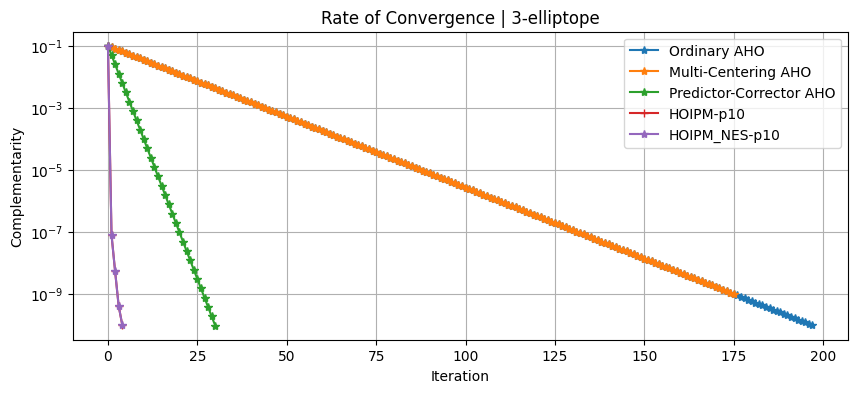

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# mu_init = np.trace(np.matmul(X_init,S_init))/ n+1


# Generate some random data
# x = np.arange(iteration+1)  # Create an array of 100 points from 0 to 10
# y = mu_record  # Add noise to a sine wave
# mu2 = [mu_init*10**(-2*(i)) for i in range(6)]

# Create a plot
plt.figure(figsize=(10, 4))  # Set the figure size
# plt.plot(x, y, label='Data')  # Plot the data
# plt.plot(x, mu2, label='Target')  # Plot the data

# plt.plot(x, mu2, label='Target')  # Plot the data
plt.plot(np.arange(len(mu_record)), mu_record, label='Ordinary AHO', marker='*')
plt.plot(np.arange(len(mu_Crecord)), mu_Crecord, label='Multi-Centering AHO', marker='*')
plt.plot(np.arange(len(mu_PCrecord)), mu_PCrecord, label='Predictor-Corrector AHO', marker='*')
plt.plot(np.arange(len(mu_rec)), mu_rec, label='HOIPM-p10', marker='+')
plt.plot(np.arange(len(mu_recNES)), mu_recNES, label='HOIPM_NES-p10', marker='*')



plt.title('Rate of Convergence | 3-elliptope')  # Set the title
plt.xlabel('Iteration')  # Set the x-axis label
plt.ylabel('Complementarity')  # Set the y-axis label
plt.yscale('log')
# plt.xticks(x)
plt.legend()  # Show legend
plt.grid()    # Show grid lines
plt.show()    # Display the plot